# SAE Explainer Visualization

This notebook rebuilds the configured target-pair visualization from saved SAE and explainer artifacts. It shows the local score-direction trace, SAE atom anchors, neighbourhood-size snapshots, and baseline manifold contour comparison without saving derived artifacts or calling LLM APIs.

## Project Root And Imports

The notebook identifies the repository root once and imports plotting/data utilities from `src`. All later cells use this single configuration path.

In [1]:
from __future__ import annotations

import pickle as pkl
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src" / "SAE").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from SAE.manifold.core import select_high_sl_anchors
from SAE.SAE_training.model import SAEConfig, SparseAutoencoder
from SAE.SAE_training.utils.data import (
    build_artifacts,
    concat_gene2vec_pair_embeddings,
    concat_geneformer_pair_embeddings,
    concat_slformer_pair_embeddings,
    extract_concat_matrix,
    gene2vec_pair_mask,
    load_cancer_id_map,
    load_gene2vec_embeddings,
    zscore_matrix,
)
from SAE.LLM_pipeline.utils.general import find_pair_index, sample_name
from SAE.SAE_training.utils.plotting import plot_manifold_topology_map, plot_topology_region_matrix
from SAE.manifold.utils.projection import encode_dataset, projection_state
from SAE.manifold.utils.visualization import (
    feature_anchor_table,
    local_trace_geometry,
    plot_local_trace,
    plot_trace_snapshots,
)

## Load Configuration And Target Data

Let $X \in \mathbb{R}^{N \times 1024}$ be the concatenated SLformer pair embedding matrix and $y \in [0,1]^N$ the SLformer score. The configured target row $x_0$ is selected by gene pair and cancer type.

In [2]:
NOTEBOOK_CONFIG = PROJECT_ROOT / "src" / "SAE" / "LLM_pipeline" / "config" / "explainer_simulator_config.yaml"
notebook_cfg = yaml.safe_load(NOTEBOOK_CONFIG.read_text(encoding="utf-8"))
train_cfg = yaml.safe_load((PROJECT_ROOT / notebook_cfg["train_config"]).read_text(encoding="utf-8"))
manifold_cfg = yaml.safe_load((PROJECT_ROOT / notebook_cfg["manifold_config"]).read_text(encoding="utf-8"))

paths_cfg = train_cfg["paths"]
scope_cfg = train_cfg["scope"]
model_cfg = SAEConfig(**dict(train_cfg["model"]))
projection_cfg = manifold_cfg["projection"]
comparison_cfg = manifold_cfg["comparison"]

TARGET_PRIMARY = str(notebook_cfg["target"]["primary_gene"])
TARGET_PARTNER = str(notebook_cfg["target"]["partner_gene"])
TARGET_CANCER = str(notebook_cfg["target"]["cancer"])
TRAIN_SCOPE = str(scope_cfg["cancer"])
SEED = int(scope_cfg["seed"])
SCORE_COL = str(scope_cfg["score_col"])
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

run_name = f"hidden{model_cfg.d_hidden}_gate{model_cfg.gate_weight}_orth{model_cfg.orth_weight}_k{model_cfg.topk}"
output_base_dir = Path(paths_cfg["output_base_dir"]).expanduser().resolve()
slformer_output_subdir = str(paths_cfg["slformer_output_subdir"])
run_dir = output_base_dir / slformer_output_subdir / TRAIN_SCOPE / run_name
output_dir = run_dir / "explanations" / f"{TARGET_CANCER}_{TARGET_PRIMARY}-{TARGET_PARTNER}"

target_manifest_path = PROJECT_ROOT / "data" / "all_SL" / "mix9_plus_idh1_prkdc" / "manifest.json"
if target_manifest_path.exists():
    target_manifest = yaml.safe_load(target_manifest_path.read_text(encoding="utf-8"))
    manifest_target = target_manifest["target"]
    use_target_manifest = (
        str(manifest_target["primary_gene"]) == TARGET_PRIMARY
        and str(manifest_target["partner_gene"]) == TARGET_PARTNER
        and str(manifest_target["cancer"]) == TARGET_CANCER
    )
else:
    use_target_manifest = False

if use_target_manifest:
    artifacts = build_artifacts(
        embeddings_pkl=Path(target_manifest["crossemb_pkl"]).expanduser().resolve(),
        prediction_csvs=[Path(path).expanduser().resolve() for path in target_manifest["prediction_csvs"]],
    )
else:
    artifacts = build_artifacts(
        embeddings_pkl=Path(paths_cfg["embeddings_pkl"]).expanduser().resolve(),
        prediction_csvs=[Path(path).expanduser().resolve() for path in paths_cfg["prediction_csvs"]],
    )
X, y, meta = extract_concat_matrix(artifacts, cancer=TRAIN_SCOPE, seed=SEED, use_score_col=SCORE_COL)
target_idx = find_pair_index(meta, TARGET_PRIMARY, TARGET_PARTNER, TARGET_CANCER)

print("Target:", sample_name(meta, target_idx), "score=", float(y[target_idx]))
print("Rows:", X.shape[0], "Embedding dim:", X.shape[1])

Target: Glioma:IDH1-PRKDC score= 0.15223628282546997
Rows: 58677 Embedding dim: 1024


## Reconstruct SAE Projection State

The normalized matrix is $X_n=(X-\mu)/(\sigma+\varepsilon)$. The local score direction $v$ is estimated from the configured tangent regression around $x_0$, and SAE activations $Z=f_{\mathrm{SAE}}(X_n)$ are encoded once for later atom placement.

In [3]:
mu = np.load(run_dir / "norm" / "mu.npy")
sigma = np.load(run_dir / "norm" / "sigma.npy")
Xn = ((X - mu) / (sigma + float(train_cfg["normalization"]["eps"]))).astype(np.float32)

checkpoint = torch.load(run_dir / "final.pt", map_location="cpu", weights_only=False)
model = SparseAutoencoder(SAEConfig(**checkpoint["sae_cfg"]))
model.load_state_dict(checkpoint["state_dict"])
model.eval().to(DEVICE)

Z = encode_dataset(model, Xn, batch_size=int(notebook_cfg["runtime"]["encode_batch_size"]), device=DEVICE)
state = projection_state(model, Xn, y, target_idx=target_idx, projection_config=projection_cfg, device=DEVICE)

feature_rank = pd.read_csv(output_dir / "feature_rank.csv")
llm_summary = pd.read_csv(output_dir / "llm_interpretation_summary.csv", keep_default_na=False)
selected_features = llm_summary["feature"].astype(int).tolist()

print("Encoded Z:", Z.shape)
print("Selected features:", selected_features)

Encoded Z: (58677, 4096)
Selected features: [3245, 3035, 1832, 459, 1403, 1949]


## Local Trace And Atom Anchors

For neighbours $x_i$, the horizontal coordinate is $t_i=(x_i-x_0)^\top v$. The two remaining coordinates are the first two PCs of $(I-vv^\top)(x_i-x_0)$. Each SAE atom anchor is an activation-weighted barycentre of core-trace coordinates.

In [4]:
LOCAL_NEIGHBOR_COUNT = 600
CORE_RADIUS_QUANTILE = 0.92
ATOM_COUNT = 24

geometry = local_trace_geometry(
    Xn,
    y,
    target_idx=target_idx,
    direction=state["direction"],
    neighbor_count=LOCAL_NEIGHBOR_COUNT,
    metric=str(projection_cfg["metric"]),
    core_radius_quantile=CORE_RADIUS_QUANTILE,
    seed=SEED,
)
atom_table = feature_anchor_table(
    model,
    Xn,
    geometry,
    feature_rank,
    llm_summary,
    atom_count=ATOM_COUNT,
    device=DEVICE,
)

display(atom_table[["feature", "joint_rank_score", "z0", "jvp", "c_star", "confidence", "anchor_t", "anchor_pc1", "anchor_pc2"]].round(4))
plot_local_trace(geometry, atom_table, title=f"{TARGET_CANCER} {TARGET_PRIMARY}-{TARGET_PARTNER}: local trace and SAE atom anchors")

,feature,joint_rank_score,z0,jvp,c_star,confidence,anchor_t,anchor_pc1,anchor_pc2
0,3245,0.850,1.9721,-0.0810,-0.0638,moderate,-3.7189,-7.8631,-0.3556
1,3035,0.770,2.4769,-0.0693,-0.0522,moderate,16.7734,3.9962,-2.4255
2,1832,0.740,2.4069,-0.0483,-0.0579,moderate,-3.5711,-0.2554,-3.8714
3,459,0.710,2.3544,-0.0630,-0.0246,moderate,NaN,NaN,NaN
4,1403,0.700,2.3875,-0.0705,-0.0078,moderate,NaN,NaN,NaN
5,1949,0.690,2.1907,0.0521,0.0202,moderate,-4.0232,0.3200,0.5576
6,1202,0.690,2.4511,0.0466,0.0328,not explained,NaN,NaN,NaN
7,3069,0.650,2.0216,0.0403,0.0485,not explained,23.7031,-3.9077,-2.3339
8,256,0.640,2.3398,-0.0407,-0.0300,not explained,-2.5417,-12.0416,-3.5536
9,2276,0.630,2.4304,0.0475,0.0005,not explained,4.7648,3.8094,-3.0714


## Baseline Manifold Inputs

For each baseline representation, construct an aligned normalized matrix $X_m$ over the same gene-pair rows. The topology visualizations use the SLformer score $s_i$ and actual label $y_i$ on these shared rows.


In [5]:
BASELINE_MAX_ANCHORS = 80
CONTOUR_FIT_K = int(comparison_cfg["fit_k"])
CONTOUR_TANGENT_DIM = int(projection_cfg["tangent_dim"])
GENE2VEC_TXT = Path("/home/tinglu/Projects/Gene2vec/pre_trained_emb/gene2vec_dim_200_iter_9_w2v.txt")
SLFORMER_TRANSFORMER_EMB_PKL = PROJECT_ROOT / "data" / "all_SL" / "mix_slformer_kg_transformeremb.pkl"
GENEFORMER_EMB_PKL = PROJECT_ROOT / "data" / "saved_data" / "map" / "geneformer_emb.pkl"
GENE2ID_PKL = PROJECT_ROOT / "data" / "saved_data" / "map" / "gene2id.pkl"
CANCER_LIST_TXT = PROJECT_ROOT / "data" / "saved_data" / "map" / "cancer_list.txt"
GENEFORMER_PREDICTION_CSVS = [PROJECT_ROOT / "data" / "all_SL" / f"pred_mix_geneformer_nokg_cv{fold}.csv" for fold in range(1, 6)]
SLFORMER_LABEL_CSVS = [PROJECT_ROOT / "data" / "merged_pred_true_slformer" / f"merged_pred_true_fold_{fold}.csv" for fold in range(1, 6)]

geneformer_prediction_parts = [pd.read_csv(path) for path in GENEFORMER_PREDICTION_CSVS]
contour_meta = pd.concat(geneformer_prediction_parts, ignore_index=True).reset_index(drop=True)
label_parts = [pd.read_csv(path) for path in SLFORMER_LABEL_CSVS]
label_table = pd.concat(label_parts, ignore_index=True).reset_index(drop=True)
contour_meta["label"] = label_table["label"].astype(int).to_numpy()
contour_meta["geneformer_probe_score"] = contour_meta["score"].astype(np.float32).to_numpy()
contour_meta["slformer_pred_score"] = label_table["pred_score"].astype(np.float32).to_numpy()
contour_y_all = contour_meta["slformer_pred_score"].to_numpy(dtype=np.float32)
contour_geneformer_probe_all = contour_meta["geneformer_probe_score"].to_numpy(dtype=np.float32)
contour_label_all = contour_meta["label"].to_numpy(dtype=np.int64)

with SLFORMER_TRANSFORMER_EMB_PKL.open("rb") as f:
    slformer_emb_folds = pkl.load(f)
with GENEFORMER_EMB_PKL.open("rb") as f:
    geneformer_emb = pkl.load(f)
with GENE2ID_PKL.open("rb") as f:
    gene2id_map = pkl.load(f)

cancer2id_map = load_cancer_id_map(CANCER_LIST_TXT)
gene2vec = load_gene2vec_embeddings(GENE2VEC_TXT)
gene2vec_mask = gene2vec_pair_mask(contour_meta, gene2vec)
geneformer_mask = (
    contour_meta["primary_gene"].astype(str).isin(gene2id_map).to_numpy()
    & contour_meta["partner_gene"].astype(str).isin(gene2id_map).to_numpy()
    & contour_meta["cancer"].astype(str).isin(cancer2id_map).to_numpy()
)
contour_mask = gene2vec_mask & geneformer_mask

contour_meta = contour_meta.loc[contour_mask].reset_index(drop=True)
contour_y = contour_y_all[contour_mask]
contour_geneformer_probe = contour_geneformer_probe_all[contour_mask]
contour_label = contour_label_all[contour_mask]
print("Aligned contour rows:", int(contour_mask.sum()))

Aligned contour rows: 58474


## Shared Anchor Pool

Select a reproducible high-SL anchor pool from the aligned rows. The later topology maps choose six diverse anchors from this pool and reuse the same anchor indices for all model representations.


In [6]:
X_slformer_contour = concat_slformer_pair_embeddings(slformer_emb_folds)[contour_mask]
X_geneformer_contour = concat_geneformer_pair_embeddings(contour_meta, geneformer_emb, gene2id_map, cancer2id_map)
X_gene2vec_contour = concat_gene2vec_pair_embeddings(contour_meta, gene2vec)

X_slformer_contour_n, _, _ = zscore_matrix(X_slformer_contour)
X_geneformer_contour_n, _, _ = zscore_matrix(X_geneformer_contour)
X_gene2vec_contour_n, _, _ = zscore_matrix(X_gene2vec_contour)

contour_anchor_candidates = select_high_sl_anchors(
    contour_y,
    contour_label,
    high_score_pool=int(comparison_cfg["high_score_pool"]),
    top_positive=int(comparison_cfg["top_positive"]),
    top_score=int(comparison_cfg["top_score"]),
    max_anchors=int(comparison_cfg["max_anchors"]),
    seed=SEED,
)
anchor_rng = np.random.default_rng(SEED)
contour_anchor_pool = np.sort(anchor_rng.choice(contour_anchor_candidates, size=BASELINE_MAX_ANCHORS, replace=False))

contour_model_matrices = {
    "SLformer": X_slformer_contour_n,
    "Geneformer-Probing": X_geneformer_contour_n,
    "Gene2Vec": X_gene2vec_contour_n,
}

print({
    "aligned_rows": int(contour_mask.sum()),
    "anchor_pool_size": int(len(contour_anchor_pool)),
    "fit_k_per_anchor": CONTOUR_FIT_K,
    "tangent_dim": CONTOUR_TANGENT_DIM,
})


{'aligned_rows': 58474, 'anchor_pool_size': 80, 'fit_k_per_anchor': 200, 'tangent_dim': 24}


## Manifold Topology Visualizations

For each model, let $M_m \in \mathbb{R}^{n_m \times 3}$ be the multi-anchor local chart with columns $(s, r_1, r_2)$, where $s$ is the fitted score direction and $(r_1,r_2)$ are residual axes. A 5-by-5 overlapping cover on $(r_1,r_2)$ gives topology regions $C_k$ with node summaries $|C_k|$, $\bar{s}_{C_k}=|C_k|^{-1}\sum_{i\in C_k}s_i$, and $\bar{y}_{C_k}=|C_k|^{-1}\sum_{i\in C_k}y_i$.

The route is computed on the Mapper graph, not drawn freely in chart space. Each graph edge is oriented from lower $\bar{s}_C$ to higher $\bar{s}_C$, and the displayed route is the adjacent-region path with the largest monotone score gain. Option 1 shows that route on the continuous manifold map; Option 3 shows the same route as numbered cover regions in the aligned matrix.


TDA anchors: [31726, 18749, 55176, 55140, 43424, 8453]
Anchor scores: [0.8928999900817871, 0.9157000184059143, 0.9437999725341797, 0.9822999835014343, 0.9933000206947327, 0.9994999766349792]


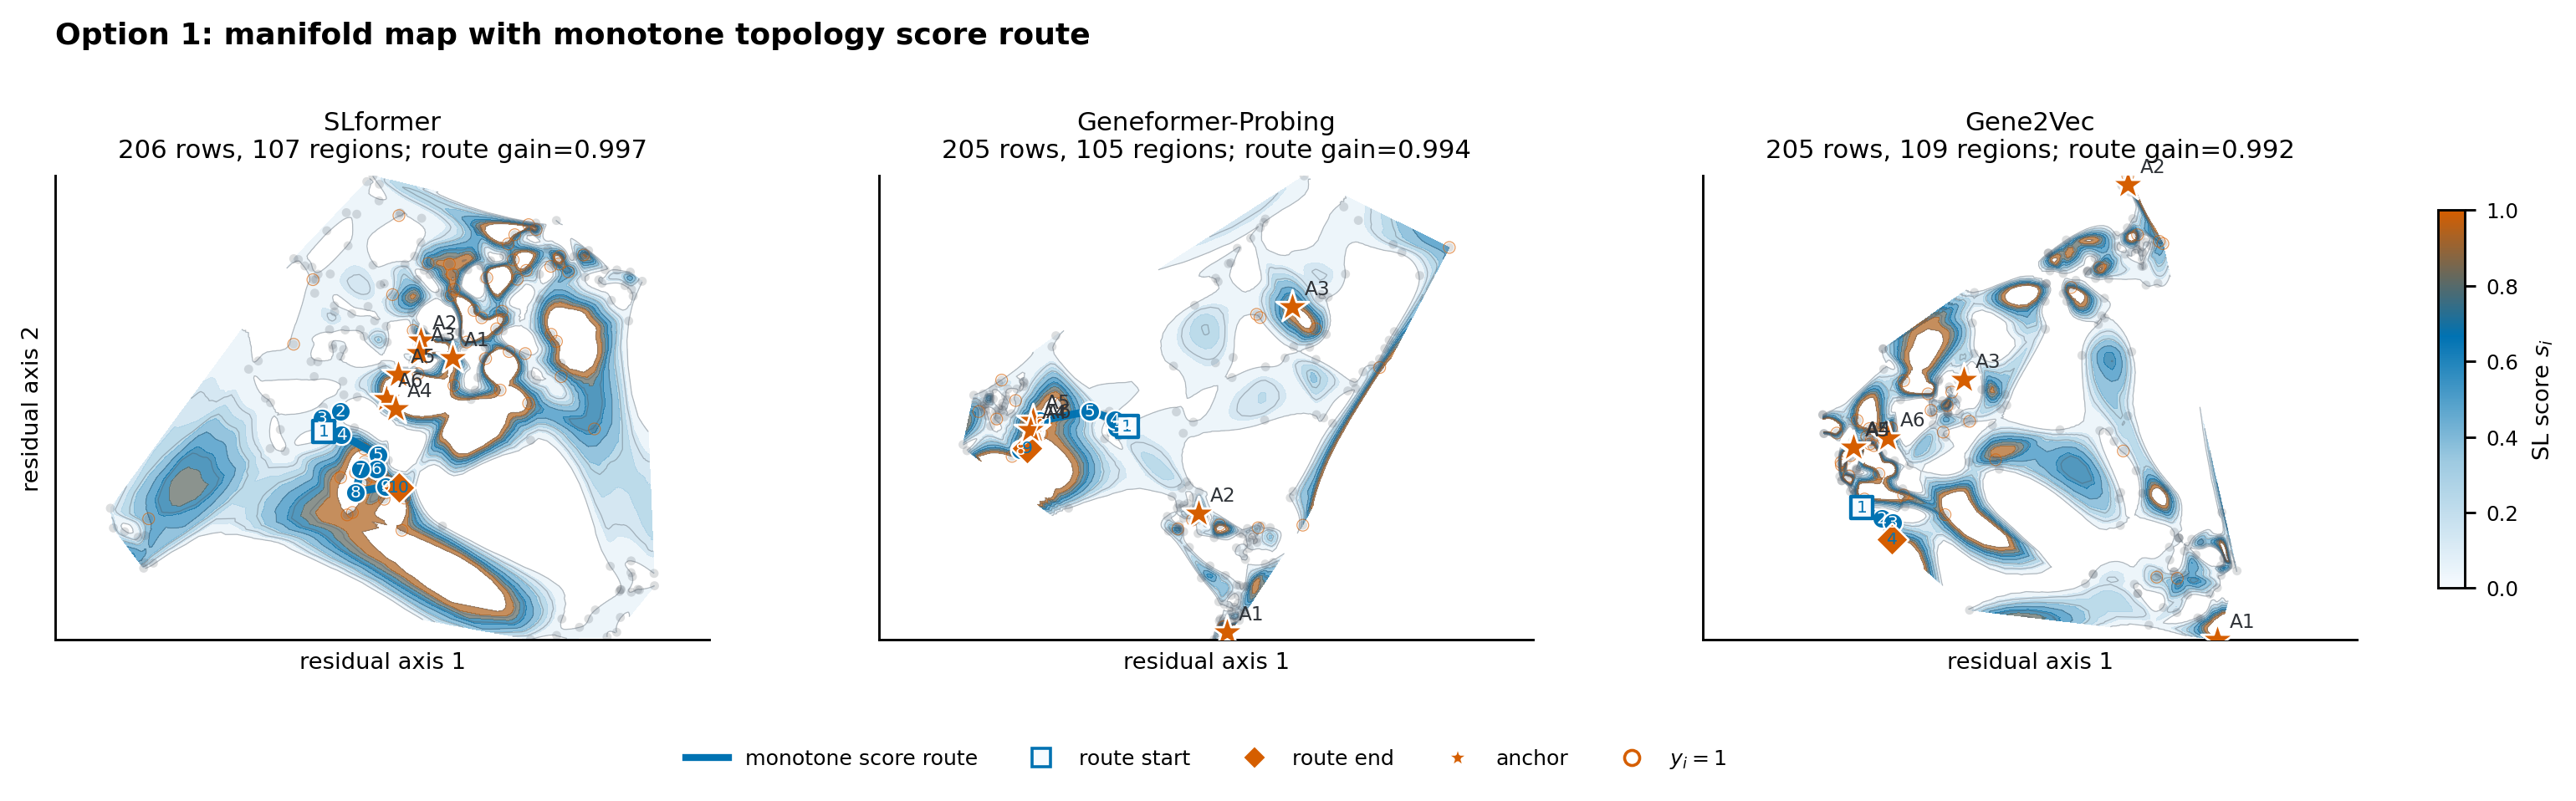

In [7]:
from SAE.manifold.core import build_cover_grid_nerve, multi_anchor_local_manifold_projection
from sklearn.neighbors import NearestNeighbors

TDA_N_ANCHORS = 6
TDA_FIT_K = CONTOUR_FIT_K
TDA_DISPLAY_K = TDA_FIT_K
TDA_N_COVERS = 15

anchor_scores = contour_y[contour_anchor_pool]
anchor_order = np.argsort(anchor_scores)
tda_anchor_indices = contour_anchor_pool[
    anchor_order[np.linspace(0, len(anchor_order) - 1, TDA_N_ANCHORS, dtype=int)]
]
tda_anchor_labels = {
    int(anchor_idx): f"A{rank + 1}"
    for rank, anchor_idx in enumerate(tda_anchor_indices)
}
print("TDA anchors:", tda_anchor_indices.tolist())
print("Anchor scores:", contour_y[tda_anchor_indices].round(4).tolist())

nerve_data: dict[str, dict] = {}
for model_name, X_model in contour_model_matrices.items():
    nn = NearestNeighbors(n_neighbors=int(TDA_FIT_K) + 1, metric="cosine").fit(X_model)
    fit_parts: list[np.ndarray] = []
    for anchor_idx in tda_anchor_indices:
        neighbors = nn.kneighbors(
            X_model[int(anchor_idx) : int(anchor_idx) + 1],
            return_distance=False,
        )[0]
        fit_parts.append(neighbors[neighbors != int(anchor_idx)][: int(TDA_FIT_K)])
    fit_indices = np.unique(np.concatenate(fit_parts))

    chart_df = multi_anchor_local_manifold_projection(
        X_model,
        contour_y,
        contour_label,
        anchor_indices=tda_anchor_indices,
        fit_indices=fit_indices[: int(TDA_DISPLAY_K)],
        tangent_dim=CONTOUR_TANGENT_DIM,
        ridge_rho=float(comparison_cfg["ridge_rho"]),
    )
    chart_df["anchor_label"] = [
        tda_anchor_labels[int(index)] if bool(is_anchor) else ""
        for index, is_anchor in zip(chart_df["index"], chart_df["is_anchor"])
    ]

    chart_3d = chart_df[["score_axis", "residual_axis_1", "residual_axis_2"]].to_numpy(dtype=float)
    nerve = build_cover_grid_nerve(
        chart_3d,
        lens_dims=(1, 2),
        n_covers=TDA_N_COVERS,
        overlap_fraction=0.35,
    )
    nerve_data[model_name] = {"nerve": nerve, "meta": chart_df}

fig = plot_manifold_topology_map(nerve_data, out_path=None)


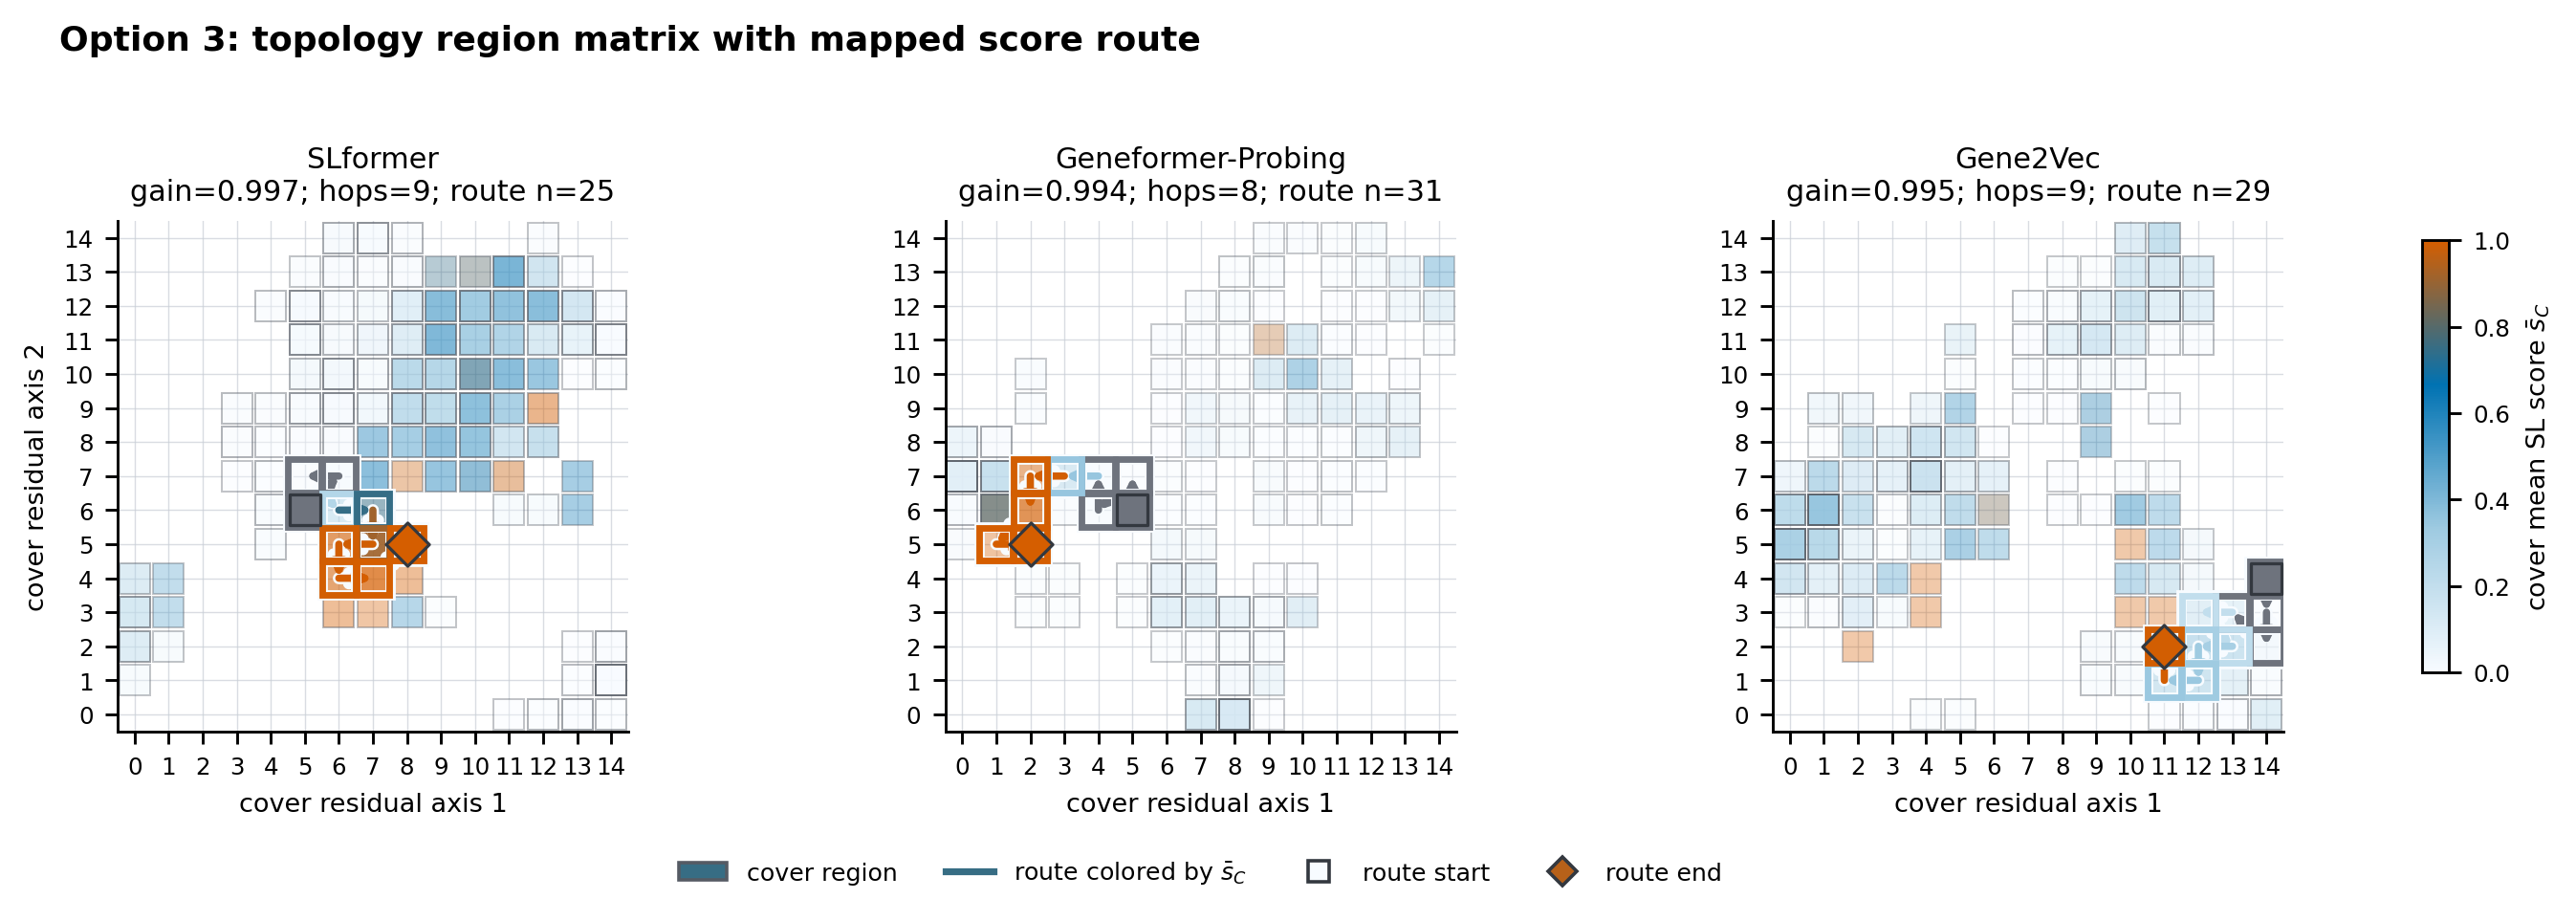

In [8]:
fig = plot_topology_region_matrix(
    nerve_data,
    out_path="output/SAE/visualization/manifold_vis/option3_topology_region_matrix.png",
)
